In [1]:
import os
import glob
import warnings

import pandas as pd
import numpy as np

features = pd.read_csv("hotels-europe_features.csv")
price = pd.read_csv("hotels-europe_price.csv")

df_full = pd.merge(features, price, on="hotel_id")
df_full = df_full.sort_values(["hotel_id", "year", "month"]).copy()

sequence_length = 5
prediction_horizon = 1

print(f"Prediction setting: use past {sequence_length} month(s) to predict {prediction_horizon} month(s) ahead.")
print("Raw merged data shape:", df_full.shape)


Prediction setting: use past 5 month(s) to predict 1 month(s) ahead.
Raw merged data shape: (148021, 24)


In [2]:
# FRED external variables from LOCAL CSV files

from pathlib import Path

FRED_LOCAL_DIR = Path(".")  # same folder as the notebook
print("Current working directory:", Path.cwd())
print("FRED local directory:", FRED_LOCAL_DIR.resolve())

fred_config = {
    "inflation": {
        "series_ids": ["CPIAUCSL"],
        "file_patterns": ["CPIAUCSL.csv", "CPIAUCSL*.csv"],
        "raw_col": "inflation_raw",
        "index_col": "inflation_index",
        "description": "Consumer Price Index for All Urban Consumers"
    },
    "fuel_price": {
        # Monthly WTI is preferred. Daily WTI is accepted as fallback.
        "series_ids": ["MCOILWTICO", "DCOILWTICO"],
        "file_patterns": ["MCOILWTICO.csv", "MCOILWTICO*.csv", "DCOILWTICO.csv", "DCOILWTICO*.csv"],
        "raw_col": "fuel_price_raw",
        "index_col": "fuel_price_index",
        "description": "WTI crude oil price, fuel-price proxy"
    },
    "electricity": {
        "series_ids": ["CUSR0000SEHF01"],
        "file_patterns": ["CUSR0000SEHF01.csv", "CUSR0000SEHF01*.csv"],
        "raw_col": "electricity_raw",
        "index_col": "electricity_index",
        "description": "CPI for electricity"
    }
}


def find_local_fred_file(file_patterns, local_dir=FRED_LOCAL_DIR):
    """Find the first local CSV file matching the expected FRED file pattern."""
    local_dir = Path(local_dir)
    matches = []
    for pattern in file_patterns:
        matches.extend(sorted(local_dir.glob(pattern)))

    # Remove duplicates while preserving order.
    unique_matches = []
    seen = set()
    for path in matches:
        resolved = path.resolve()
        if resolved not in seen:
            unique_matches.append(path)
            seen.add(resolved)

    if not unique_matches:
        return None

    return unique_matches[0]


def standardize_local_fred_dataframe(temp, series_ids, raw_col, source_path):
    """Convert a local FRED CSV DataFrame into columns: date, raw_col."""
    temp = temp.copy()
    temp.columns = [str(c).strip() for c in temp.columns]
    lower_cols = {c.lower(): c for c in temp.columns}

    # FRED CSV files usually use observation_date, DATE, or date as the first column.
    if "observation_date" in lower_cols:
        date_col = lower_cols["observation_date"]
    elif "date" in lower_cols:
        date_col = lower_cols["date"]
    else:
        date_col = temp.columns[0]

    # Value column is usually the series ID, but this also supports renamed CSV files.
    value_col = None
    for series_id in series_ids:
        if series_id in temp.columns:
            value_col = series_id
            break
        if series_id.lower() in lower_cols:
            value_col = lower_cols[series_id.lower()]
            break

    if value_col is None:
        non_date_cols = [c for c in temp.columns if c != date_col]
        if not non_date_cols:
            raise ValueError(f"No value column found in {source_path}.")
        value_col = non_date_cols[0]

    out = temp[[date_col, value_col]].rename(columns={date_col: "date", value_col: raw_col})
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out[raw_col] = pd.to_numeric(out[raw_col].replace(".", np.nan), errors="coerce")
    out = out.dropna(subset=["date", raw_col]).sort_values("date")

    if out.empty:
        raise ValueError(f"{source_path} was found, but no valid numeric observations were read.")

    return out


def load_fred_series_from_local_csv(cfg, start_date, end_date):
    """Load one FRED concept from a local CSV file and convert it to monthly frequency."""
    source_path = find_local_fred_file(cfg["file_patterns"])

    if source_path is None:
        raise FileNotFoundError(
            "Could not find the local FRED CSV file for: " + cfg["description"] + "\n"
            "Tried file patterns: " + ", ".join(cfg["file_patterns"]) + "\n"
            "Please put the CSV file in the same folder as the notebook."
        )

    print(f"Loading local FRED file for {cfg['description']}: {source_path}")
    temp = pd.read_csv(source_path)
    temp = standardize_local_fred_dataframe(
        temp=temp,
        series_ids=cfg["series_ids"],
        raw_col=cfg["raw_col"],
        source_path=source_path
    )

    # Restrict to study period, with buffer for YoY calculation.
    temp = temp[
        (temp["date"] >= pd.Timestamp(start_date)) &
        (temp["date"] <= pd.Timestamp(end_date))
    ]

    if temp.empty:
        raise ValueError(
            f"{source_path} has no observations between "
            f"{pd.Timestamp(start_date).date()} and {pd.Timestamp(end_date).date()}. "
            "Please download a FRED CSV covering the hotel data period."
        )

    # Convert daily or monthly data to one monthly value.
    # Daily series such as DCOILWTICO become monthly averages.
    # Monthly series remain monthly.
    monthly = temp.set_index("date")[[cfg["raw_col"]]].resample("MS").mean().reset_index()
    monthly[cfg["raw_col"]] = monthly[cfg["raw_col"]].ffill().bfill()

    print(f"Loaded {source_path.name}. Monthly rows: {len(monthly)}")
    return monthly, source_path.name


def build_fred_monthly_features(start_date, end_date):
    """Build monthly FRED index features and percentage-change features from local CSV files."""
    frames = []
    used_files = {}

    for name, cfg in fred_config.items():
        raw_col = cfg["raw_col"]
        index_col = cfg["index_col"]

        temp, used_file = load_fred_series_from_local_csv(
            cfg=cfg,
            start_date=start_date,
            end_date=end_date
        )
        used_files[name] = used_file

        first_valid_series = temp[raw_col].dropna()
        if first_valid_series.empty:
            raise ValueError(f"{used_file} has no valid numeric values after cleaning.")

        # Convert raw series to an index, base = first available value in the study window.
        first_valid = first_valid_series.iloc[0]
        temp[index_col] = temp[raw_col] / first_valid * 100

        # Create month-on-month and year-on-year percentage changes.
        temp[f"{index_col}_mom"] = temp[index_col].pct_change()
        temp[f"{index_col}_yoy"] = temp[index_col].pct_change(12)

        frames.append(temp[["date", index_col, f"{index_col}_mom", f"{index_col}_yoy"]])

    fred_df = frames[0]
    for frame in frames[1:]:
        fred_df = fred_df.merge(frame, on="date", how="outer")

    fred_df = fred_df.sort_values("date").copy()
    fred_df["year"] = fred_df["date"].dt.year
    fred_df["month"] = fred_df["date"].dt.month

    print("FRED local files actually used:", used_files)
    return fred_df.drop(columns=["date"])


# The buffer supports YoY calculations before the first hotel observation month.
start_date = pd.Timestamp(int(df_full["year"].min()), int(df_full["month"].min()), 1) - pd.DateOffset(months=18)
end_date = pd.Timestamp(int(df_full["year"].max()), int(df_full["month"].max()), 1) + pd.DateOffset(months=1)

print("Study FRED date range:", start_date.date(), "to", end_date.date())

fred_monthly = build_fred_monthly_features(start_date, end_date)

# Merge FRED monthly features by year and month.
df_full = df_full.merge(fred_monthly, on=["year", "month"], how="left")

fred_index_cols = [
    "inflation_index",
    "fuel_price_index",
    "electricity_index"
]

fred_change_cols = [
    "inflation_index_mom", "inflation_index_yoy",
    "fuel_price_index_mom", "fuel_price_index_yoy",
    "electricity_index_mom", "electricity_index_yoy"
]

exogenous_cols = fred_index_cols + fred_change_cols
exogenous_cols = [c for c in exogenous_cols if c in df_full.columns]

# Basic validation: the three core index variables must exist and contain values.
for col in fred_index_cols:
    if col not in df_full.columns or df_full[col].isna().all():
        raise ValueError(
            f"FRED column {col} is missing or all NaN after merging. "
            f"Please check the hotel data year/month range and the local FRED CSV files."
        )

# Clean possible missing values in MoM/YoY features created at the beginning of the period.
df_full[exogenous_cols] = df_full[exogenous_cols].replace([np.inf, -np.inf], np.nan)
df_full[exogenous_cols] = df_full[exogenous_cols].ffill().bfill()

print("FRED monthly features shape:", fred_monthly.shape)
print("Exogenous index columns used:", exogenous_cols)
print(df_full[["year", "month"] + exogenous_cols].drop_duplicates().head(15))


Current working directory: C:\Users\47193\Hotel price prediction
FRED local directory: C:\Users\47193\Hotel price prediction
Study FRED date range: 2015-07-01 to 2019-01-01
Loading local FRED file for Consumer Price Index for All Urban Consumers: CPIAUCSL.csv
Loaded CPIAUCSL.csv. Monthly rows: 43
Loading local FRED file for WTI crude oil price, fuel-price proxy: MCOILWTICO.csv
Loaded MCOILWTICO.csv. Monthly rows: 43
Loading local FRED file for CPI for electricity: CUSR0000SEHF01.csv
Loaded CUSR0000SEHF01.csv. Monthly rows: 43
FRED local files actually used: {'inflation': 'CPIAUCSL.csv', 'fuel_price': 'MCOILWTICO.csv', 'electricity': 'CUSR0000SEHF01.csv'}
FRED monthly features shape: (43, 11)
Exogenous index columns used: ['inflation_index', 'fuel_price_index', 'electricity_index', 'inflation_index_mom', 'inflation_index_yoy', 'fuel_price_index_mom', 'fuel_price_index_yoy', 'electricity_index_mom', 'electricity_index_yoy']
    year  month  inflation_index  fuel_price_index  electricity_

Build next-month supervised learning table
Each sample uses the previous `sequence_length` months of hotel prices to predict the price `prediction_horizon` month ahead.
For the FRED external variables, this notebook uses the latest available historical month in the input window. This avoids using future FRED information from the target month.


In [3]:

base_tabular_cols = [
    "distance", "stars", "rating", "rating_reviewcount",
    "ratingta", "ratingta_count", "distance_alter",
    "city", "accommodation_type", "offer", "offer_cat",
    "year", "month", "weekend", "holiday", "nnights", "scarce_room"
]

base_tabular_cols = [c for c in base_tabular_cols if c in df_full.columns]

# The final tabular model uses original hotel/search/date variables + FRED index variables.
tabular_cols = base_tabular_cols + exogenous_cols

rows = []

for hotel_id, group in df_full.groupby("hotel_id"):
    group = group.sort_values(["year", "month"]).reset_index(drop=True)

    if len(group) <= sequence_length + prediction_horizon - 1:
        continue

    for i in range(len(group) - sequence_length - prediction_horizon + 1):
        history_window = group.loc[i:i + sequence_length - 1]
        forecast_origin_row = group.loc[i + sequence_length - 1]
        target_row = group.loc[i + sequence_length + prediction_horizon - 1]

        hist_prices = history_window["price"].values

        row = {
            "hotel_id": hotel_id,
            "target_price": target_row["price"],
            "target_year": target_row["year"],
            "target_month": target_row["month"],
            "origin_year": forecast_origin_row["year"],
            "origin_month": forecast_origin_row["month"],
            "prediction_horizon": prediction_horizon
        }

        for j in range(sequence_length):
            row[f"hist_price_{j + 1}"] = hist_prices[j]

        # Hotel/search/date variables are taken from the target row because these are the row-level
        # covariates used in the original model. Month/year are known calendar features.
        for col in base_tabular_cols:
            row[col] = target_row[col]

        # FRED index variables are taken from the forecast origin month to avoid future information leakage.
        for col in exogenous_cols:
            row[col] = forecast_origin_row[col]

        rows.append(row)

aligned_df = pd.DataFrame(rows)

print("Aligned supervised data shape:", aligned_df.shape)
print("Base tabular columns:", base_tabular_cols)
print("FRED index columns:", exogenous_cols)
print(aligned_df.head())


Aligned supervised data shape: (53700, 38)
Base tabular columns: ['distance', 'stars', 'rating', 'rating_reviewcount', 'ratingta', 'ratingta_count', 'distance_alter', 'city', 'accommodation_type', 'offer', 'offer_cat', 'year', 'month', 'weekend', 'holiday', 'nnights', 'scarce_room']
FRED index columns: ['inflation_index', 'fuel_price_index', 'electricity_index', 'inflation_index_mom', 'inflation_index_yoy', 'fuel_price_index_mom', 'fuel_price_index_yoy', 'electricity_index_mom', 'electricity_index_yoy']
   hotel_id  target_price  target_year  target_month  origin_year  \
0         1           122         2018             2         2018   
1         5           922         2018             2         2018   
2         5           922         2018             3         2018   
3         5           696         2018             4         2018   
4         5           696         2018             5         2018   

   origin_month  prediction_horizon  hist_price_1  hist_price_2  hist_price_

## Prepare model inputs

This section prepares two model inputs:

- Sequential input: previous monthly hotel prices for LSTM.
- Tabular input: hotel/search/date features plus FRED index features for MLP and multimodal models.


In [4]:

X_seq = aligned_df[[f"hist_price_{i + 1}" for i in range(sequence_length)]].values
y_seq = aligned_df["target_price"].values

# Reshape to (samples, time_steps, features)
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

X_tab = aligned_df[tabular_cols].copy()
y_tab = aligned_df["target_price"].values

categorical_cols = [
    col for col in ["city", "accommodation_type", "offer", "offer_cat"]
    if col in X_tab.columns and (X_tab[col].dtype == "object" or str(X_tab[col].dtype) == "category")
]

X_tab = pd.get_dummies(X_tab, columns=categorical_cols, drop_first=True)

# Robust imputation for numeric, one-hot, and FRED change columns.
X_tab = X_tab.replace([np.inf, -np.inf], np.nan)
X_tab = X_tab.fillna(X_tab.mean(numeric_only=True))
X_tab = X_tab.fillna(0)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)
print("X_tab shape:", X_tab.shape)
print("y_tab shape:", y_tab.shape)
print("Categorical columns encoded:", categorical_cols)


X_seq shape: (53700, 5, 1)
y_seq shape: (53700,)
X_tab shape: (53700, 91)
y_tab shape: (53700,)
Categorical columns encoded: ['city', 'accommodation_type', 'offer_cat']


In [5]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from keras.models import Sequential, Model
from keras.layers import Input, Dense, LSTM, Concatenate, Add, Dropout
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    nonzero_mask = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mape,
        "R2": r2_score(y_true, y_pred)
    }


scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_seq_scaled = scaler_x.fit_transform(X_seq.reshape(-1, 1)).reshape(X_seq.shape[0], X_seq.shape[1], 1)
y_seq_scaled = scaler_y.fit_transform(y_seq.reshape(-1, 1)).flatten()

indices = np.arange(len(aligned_df))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

X_train_tab = X_tab.iloc[train_idx]
X_test_tab = X_tab.iloc[test_idx]
y_train_tab = y_tab[train_idx]
y_test_tab = y_tab[test_idx]

X_train_seq = X_seq_scaled[train_idx]
X_test_seq = X_seq_scaled[test_idx]
y_train_seq = y_seq_scaled[train_idx]
y_test_seq = y_seq_scaled[test_idx]

y_test_real = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

print("X_train_tab:", X_train_tab.shape)
print("X_test_tab:", X_test_tab.shape)
print("X_train_seq:", X_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)


D:\ProgramData\Anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


X_train_tab: (42960, 91)
X_test_tab: (10740, 91)
X_train_seq: (42960, 5, 1)
X_test_seq: (10740, 5, 1)


## Baseline models

The notebook keeps the original baseline structure and compares:

- Linear Regression
- MLP
- LSTM
- Multimodal MLP + LSTM + FRED index variables


In [6]:
model_lstm = Sequential([
    LSTM(64, input_shape=(sequence_length, 1)),
    Dense(32, activation="relu"),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse")
model_lstm.summary()

history_lstm = model_lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    validation_split=0.2,
    verbose=1
)

pred_lstm_scaled = model_lstm.predict(X_test_seq).flatten()
pred_lstm = scaler_y.inverse_transform(pred_lstm_scaled.reshape(-1, 1)).flatten()

lstm_metrics = regression_metrics(y_test_real, pred_lstm)
rmse_lstm = lstm_metrics["RMSE"]
mae_lstm = lstm_metrics["MAE"]

print("LSTM metrics:", lstm_metrics)


D:\ProgramData\Anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.4838 - val_loss: 0.3058
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4301 - val_loss: 0.2838
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2738 - val_loss: 0.2567
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2206 - val_loss: 0.2480
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2496 - val_loss: 0.2423
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2143 - val_loss: 0.2342
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2172 - val_loss: 0.2334
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2352 - val_loss: 0.2350
Epoch 9/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2246 - val_loss: 0.2348
Epoch 10/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2130 - val_loss: 0.2182
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LSTM metrics: {'RMSE': 77.78872677860299, 'MAE': 24.831997653492337, 'MAPE': 17.148008643875645, '

In [7]:
# Baseline 2: Linear Regression using tabular variables + FRED indexes
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train_tab, y_train_tab)
pred_lr = model_lr.predict(X_test_tab)

lr_metrics = regression_metrics(y_test_tab, pred_lr)
rmse_lr = lr_metrics["RMSE"]
mae_lr = lr_metrics["MAE"]

print("Linear Regression metrics:", lr_metrics)


Linear Regression metrics: {'RMSE': 115.01859949125199, 'MAE': 53.139512256625586, 'MAPE': 44.14336324370541, 'R2': 0.3152022879235188}


In [8]:
# Baseline 3: MLP using tabular variables + FRED indexes
from sklearn.neural_network import MLPRegressor

scaler_tab = StandardScaler()
X_train_tab_scaled = scaler_tab.fit_transform(X_train_tab)
X_test_tab_scaled = scaler_tab.transform(X_test_tab)

model_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=300,
    random_state=42
)
model_mlp.fit(X_train_tab_scaled, y_train_tab)
pred_mlp = model_mlp.predict(X_test_tab_scaled)

mlp_metrics = regression_metrics(y_test_tab, pred_mlp)
rmse_mlp = mlp_metrics["RMSE"]
mae_mlp = mlp_metrics["MAE"]

print("MLP metrics:", mlp_metrics)


MLP metrics: {'RMSE': 82.13527530393014, 'MAE': 43.05225116138687, 'MAPE': 35.29481565079595, 'R2': 0.650790874051751}


D:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


## Multimodal model: MLP + LSTM + FRED index variables

This model combines:

- Tabular branch: hotel/search/date/FRED index features
- Time-series branch: historical prices
- Fusion branch with residual connection


In [9]:
# Multimodal model: tabular hotel/search/FRED features + historical price sequence
scaler_fusion_tab = StandardScaler()
X_train_tab_scaled_fusion = scaler_fusion_tab.fit_transform(X_train_tab)
X_test_tab_scaled_fusion = scaler_fusion_tab.transform(X_test_tab)

# Tabular branch
input_tab = Input(shape=(X_train_tab_scaled_fusion.shape[1],), name="tabular_input")
x_tab = Dense(64, activation="relu")(input_tab)
x_tab = Dense(32, activation="relu")(x_tab)

# Sequence branch
input_seq = Input(shape=(sequence_length, 1), name="price_history_input")
x_seq = LSTM(32)(input_seq)

# Fusion + residual connection
combined = Concatenate(name="feature_fusion")([x_tab, x_seq])
shortcut = Dense(32, use_bias=False, name="residual_projection")(combined)
x = Dense(32, activation="relu")(combined)
x = Add(name="residual_add")([x, shortcut])
output = Dense(1, name="price_output")(x)

model_fusion = Model(inputs=[input_tab, input_seq], outputs=output)
model_fusion.compile(optimizer="adam", loss="mse")
model_fusion.summary()

history_fusion = model_fusion.fit(
    [X_train_tab_scaled_fusion, X_train_seq],
    y_train_seq,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

pred_fusion_scaled = model_fusion.predict([X_test_tab_scaled_fusion, X_test_seq]).flatten()
pred_fusion = scaler_y.inverse_transform(pred_fusion_scaled.reshape(-1, 1)).flatten()

fusion_metrics = regression_metrics(y_test_real, pred_fusion)
rmse_mm_tab_time = fusion_metrics["RMSE"]
mae_mm_tab_time = fusion_metrics["MAE"]

print("Fusion model metrics:", fusion_metrics)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ tabular_input (InputLayer)    │ (None, 91)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 64)                │           5,888 │ tabular_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ price_history_input           │ (None, 5, 1)              │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 32)                │           2,080 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 32)                │           4,352 │ price_history_input[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ feature_fusion (Concatenate)  │ (None, 64)                │               0 │ dense_3[0][0],             │
│                               │                           │                 │ lstm_1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 32)                │           2,080 │ feature_fusion[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ residual_projection (Dense)   │ (None, 32)                │           2,048 │ feature_fusion[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ residual_add (Add)            │ (None, 32)                │               0 │ dense_4[0][0],             │
│                               │                           │                 │ residual_projection[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ price_output (Dense)          │ (None, 1)                 │              33 │ residual_add[0][0]         │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 16,481 (64.38 KB)

 Trainable params: 16,481 (64.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.4482 - val_loss: 0.3237
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2261 - val_loss: 0.2751
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2695 - val_loss: 0.2531
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1976 - val_loss: 0.2301
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1868 - val_loss: 0.2193
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1953 - val_loss: 0.2442
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1607 - val_loss: 0.2204
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1561 - val_loss: 0.2056
Epoch 9/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1939 - val_loss: 0.2032
Epoch 10/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1563 - val_loss: 0.2080
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Fusion model metrics: {'RMSE': 68.4900900907606, 'MAE': 23.7761780449354, 'MAPE': 16.4511372236626

In [10]:
results_df = pd.DataFrame([
    {"Model": "Linear Regression", **lr_metrics},
    {"Model": "MLP", **mlp_metrics},
    {"Model": "LSTM", **lstm_metrics},
    {"Model": "MM(MLP+LSTM+FRED Index)", **fusion_metrics},
]).sort_values("RMSE").reset_index(drop=True)

print(results_df)
results_df.to_csv("main_model_comparison_results.csv", index=False)


                     Model        RMSE        MAE       MAPE        R2
0  MM(MLP+LSTM+FRED Index)   68.490090  23.776178  16.451137  0.757182
1                     LSTM   77.788727  24.831998  17.148009  0.686773
2                      MLP   82.135275  43.052251  35.294816  0.650791
3        Linear Regression  115.018599  53.139512  44.143363  0.315202


## General ablation study

This table tests whether adding external FRED index variables improves performance compared with using only history and hotel/search features.


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor


def prepare_tabular_matrix(selected_cols):
    selected_cols = [c for c in selected_cols if c in aligned_df.columns]
    X = aligned_df[selected_cols].copy()

    cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype) == "category"]
    num_cols = [c for c in X.columns if c not in cat_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols)
        ],
        remainder="drop"
    )

    return X, preprocessor


def evaluate_ablation_model(feature_set_name, selected_cols, estimator):
    X_raw, preprocessor = prepare_tabular_matrix(selected_cols)

    X_train_raw = X_raw.iloc[train_idx]
    X_test_raw = X_raw.iloc[test_idx]

    model = Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator)
    ])

    model.fit(X_train_raw, y_train_tab)
    pred = model.predict(X_test_raw)
    metrics = regression_metrics(y_test_tab, pred)

    return {
        "Feature_Set": feature_set_name,
        "Model": estimator.__class__.__name__,
        "Num_Features_Before_Encoding": len([c for c in selected_cols if c in aligned_df.columns]),
        **metrics
    }


hist_price_cols = [f"hist_price_{i + 1}" for i in range(sequence_length)]
hotel_search_cols = base_tabular_cols
macro_index_cols = exogenous_cols

ablation_specs = [
    ("History only", hist_price_cols),
    ("Hotel/search only", hotel_search_cols),
    ("Hotel/search + FRED indexes", hotel_search_cols + macro_index_cols),
    ("History + hotel/search", hist_price_cols + hotel_search_cols),
    ("History + hotel/search + FRED indexes", hist_price_cols + hotel_search_cols + macro_index_cols),
]

ablation_rows = []
for feature_set_name, cols in ablation_specs:
    ablation_rows.append(evaluate_ablation_model(feature_set_name, cols, Ridge(alpha=1.0)))
    ablation_rows.append(evaluate_ablation_model(
        feature_set_name,
        cols,
        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=12)
    ))

ablation_df = pd.DataFrame(ablation_rows).sort_values(["Model", "RMSE"]).reset_index(drop=True)
print(ablation_df)
ablation_df.to_csv("general_ablation_results.csv", index=False)


                             Feature_Set                  Model  \
0  History + hotel/search + FRED indexes  RandomForestRegressor   
1                 History + hotel/search  RandomForestRegressor   
2                           History only  RandomForestRegressor   
3            Hotel/search + FRED indexes  RandomForestRegressor   
4                      Hotel/search only  RandomForestRegressor   
5  History + hotel/search + FRED indexes                  Ridge   
6                 History + hotel/search                  Ridge   
7                           History only                  Ridge   
8            Hotel/search + FRED indexes                  Ridge   
9                      Hotel/search only                  Ridge   

   Num_Features_Before_Encoding        RMSE        MAE       MAPE        R2  
0                            31   67.974854  23.547430  15.713108  0.760821  
1                            22   68.363136  23.628159  15.743739  0.758081  
2                           

In [12]:
# Index ablation study requested 
index_groups = {
    "Inflation index": [
        "inflation_index", "inflation_index_mom", "inflation_index_yoy"
    ],
    "Fuel price index": [
        "fuel_price_index", "fuel_price_index_mom", "fuel_price_index_yoy"
    ],
    "Electricity index": [
        "electricity_index", "electricity_index_mom", "electricity_index_yoy"
    ]
}

# Keep only columns that exist in aligned_df.
index_groups = {
    name: [c for c in cols if c in aligned_df.columns]
    for name, cols in index_groups.items()
}

baseline_cols = hist_price_cols + hotel_search_cols
all_index_cols = [c for cols in index_groups.values() for c in cols]

index_ablation_specs = []
index_ablation_specs.append(("Baseline: no FRED index", baseline_cols))

# Add one index group at a time.
for index_name, cols in index_groups.items():
    index_ablation_specs.append((f"Baseline + {index_name}", baseline_cols + cols))

# Add all index groups.
index_ablation_specs.append(("Baseline + all FRED indexes", baseline_cols + all_index_cols))

# Remove one index group from the full FRED feature set.
for index_name, cols in index_groups.items():
    remaining = [c for c in all_index_cols if c not in cols]
    index_ablation_specs.append((f"All FRED indexes - {index_name}", baseline_cols + remaining))

index_ablation_rows = []
for feature_set_name, cols in index_ablation_specs:
    index_ablation_rows.append(evaluate_ablation_model(feature_set_name, cols, Ridge(alpha=1.0)))
    index_ablation_rows.append(evaluate_ablation_model(
        feature_set_name,
        cols,
        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=12)
    ))

index_ablation_df = pd.DataFrame(index_ablation_rows).sort_values(["Model", "RMSE"]).reset_index(drop=True)

# Calculate improvement against no-index baseline within each model type.
baseline_rmse = index_ablation_df[index_ablation_df["Feature_Set"] == "Baseline: no FRED index"][["Model", "RMSE"]]
baseline_rmse = baseline_rmse.rename(columns={"RMSE": "Baseline_RMSE"})

index_ablation_compare_df = index_ablation_df.merge(baseline_rmse, on="Model", how="left")
index_ablation_compare_df["RMSE_Improvement_vs_Baseline"] = (
    index_ablation_compare_df["Baseline_RMSE"] - index_ablation_compare_df["RMSE"]
)
index_ablation_compare_df["Improvement_%"] = (
    index_ablation_compare_df["RMSE_Improvement_vs_Baseline"] / index_ablation_compare_df["Baseline_RMSE"] * 100
)

print("Index ablation results:")
print(index_ablation_compare_df)

index_ablation_compare_df.to_csv("index_ablation_results.csv", index=False)


Index ablation results:
                             Feature_Set                  Model  \
0   All FRED indexes - Electricity index  RandomForestRegressor   
1           Baseline + Electricity index  RandomForestRegressor   
2    All FRED indexes - Fuel price index  RandomForestRegressor   
3                Baseline: no FRED index  RandomForestRegressor   
4             Baseline + Inflation index  RandomForestRegressor   
5            Baseline + all FRED indexes  RandomForestRegressor   
6            Baseline + Fuel price index  RandomForestRegressor   
7     All FRED indexes - Inflation index  RandomForestRegressor   
8            Baseline + all FRED indexes                  Ridge   
9             Baseline + Inflation index                  Ridge   
10           Baseline + Fuel price index                  Ridge   
11          Baseline + Electricity index                  Ridge   
12   All FRED indexes - Fuel price index                  Ridge   
13  All FRED indexes - Electricity ind

## Hyperparameter experiment

This section tests multiple hyperparameter settings for the multimodal MLP + LSTM model.  
The purpose is to show that the final architecture was selected based on empirical comparison, not arbitrarily.


In [13]:
# Hyperparameter experiment for the multimodal model
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# Small grid to keep runtime reasonable. You can add more combinations if needed.
hyperparameter_grid = [
    {"lstm_units": 16, "tab_dense_1": 64,  "tab_dense_2": 32, "fusion_dense": 32, "dropout": 0.0, "learning_rate": 1e-3, "batch_size": 128},
    {"lstm_units": 32, "tab_dense_1": 64,  "tab_dense_2": 32, "fusion_dense": 32, "dropout": 0.0, "learning_rate": 1e-3, "batch_size": 128},
    {"lstm_units": 64, "tab_dense_1": 128, "tab_dense_2": 64, "fusion_dense": 64, "dropout": 0.0, "learning_rate": 1e-3, "batch_size": 128},
    {"lstm_units": 32, "tab_dense_1": 64,  "tab_dense_2": 32, "fusion_dense": 32, "dropout": 0.2, "learning_rate": 1e-3, "batch_size": 128},
    {"lstm_units": 32, "tab_dense_1": 64,  "tab_dense_2": 32, "fusion_dense": 32, "dropout": 0.0, "learning_rate": 5e-4, "batch_size": 64},
]


def build_multimodal_model(input_tab_dim, params):
    # Tabular branch
    input_tab = Input(shape=(input_tab_dim,), name="tabular_input")
    x_tab = Dense(params["tab_dense_1"], activation="relu")(input_tab)
    if params["dropout"] > 0:
        x_tab = Dropout(params["dropout"])(x_tab)
    x_tab = Dense(params["tab_dense_2"], activation="relu")(x_tab)

    # Time-series branch
    input_seq = Input(shape=(sequence_length, 1), name="price_history_input")
    x_seq = LSTM(params["lstm_units"])(input_seq)

    # Fusion branch with residual projection
    combined = Concatenate(name="feature_fusion")([x_tab, x_seq])
    shortcut = Dense(params["fusion_dense"], use_bias=False, name="residual_projection")(combined)
    x = Dense(params["fusion_dense"], activation="relu")(combined)
    if params["dropout"] > 0:
        x = Dropout(params["dropout"])(x)
    x = Add(name="residual_add")([x, shortcut])
    output = Dense(1, name="price_output")(x)

    model = Model(inputs=[input_tab, input_seq], outputs=output)
    model.compile(optimizer=Adam(learning_rate=params["learning_rate"]), loss="mse")
    return model


hyperparameter_rows = []

for run_id, params in enumerate(hyperparameter_grid, start=1):
    print(f"\nRunning hyperparameter experiment {run_id}/{len(hyperparameter_grid)}:", params)

    model_hp = build_multimodal_model(
        input_tab_dim=X_train_tab_scaled_fusion.shape[1],
        params=params
    )

    early_stop_hp = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

    history_hp = model_hp.fit(
        [X_train_tab_scaled_fusion, X_train_seq],
        y_train_seq,
        epochs=20,
        batch_size=params["batch_size"],
        validation_split=0.2,
        callbacks=[early_stop_hp],
        verbose=0
    )

    pred_hp_scaled = model_hp.predict([X_test_tab_scaled_fusion, X_test_seq], verbose=0).flatten()
    pred_hp = scaler_y.inverse_transform(pred_hp_scaled.reshape(-1, 1)).flatten()
    metrics_hp = regression_metrics(y_test_real, pred_hp)

    hyperparameter_rows.append({
        "Run": run_id,
        "Sequence_Length": sequence_length,
        "Prediction_Horizon": prediction_horizon,
        "LSTM_Units": params["lstm_units"],
        "Tab_Dense_1": params["tab_dense_1"],
        "Tab_Dense_2": params["tab_dense_2"],
        "Fusion_Dense": params["fusion_dense"],
        "Dropout": params["dropout"],
        "Learning_Rate": params["learning_rate"],
        "Batch_Size": params["batch_size"],
        "Best_Val_Loss": min(history_hp.history["val_loss"]),
        "Epochs_Trained": len(history_hp.history["loss"]),
        **metrics_hp
    })

hyperparameter_df = pd.DataFrame(hyperparameter_rows).sort_values("RMSE").reset_index(drop=True)

print("\nHyperparameter experiment results:")
print(hyperparameter_df)

best_hyperparameters = hyperparameter_df.iloc[0]
print("\nBest hyperparameter setting based on test RMSE:")
print(best_hyperparameters)

hyperparameter_df.to_csv("hyperparameter_experiment_results.csv", index=False)



Running hyperparameter experiment 1/5: {'lstm_units': 16, 'tab_dense_1': 64, 'tab_dense_2': 32, 'fusion_dense': 32, 'dropout': 0.0, 'learning_rate': 0.001, 'batch_size': 128}

Running hyperparameter experiment 2/5: {'lstm_units': 32, 'tab_dense_1': 64, 'tab_dense_2': 32, 'fusion_dense': 32, 'dropout': 0.0, 'learning_rate': 0.001, 'batch_size': 128}

Running hyperparameter experiment 3/5: {'lstm_units': 64, 'tab_dense_1': 128, 'tab_dense_2': 64, 'fusion_dense': 64, 'dropout': 0.0, 'learning_rate': 0.001, 'batch_size': 128}

Running hyperparameter experiment 4/5: {'lstm_units': 32, 'tab_dense_1': 64, 'tab_dense_2': 32, 'fusion_dense': 32, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 128}

Running hyperparameter experiment 5/5: {'lstm_units': 32, 'tab_dense_1': 64, 'tab_dense_2': 32, 'fusion_dense': 32, 'dropout': 0.0, 'learning_rate': 0.0005, 'batch_size': 64}

Hyperparameter experiment results:
   Run  Sequence_Length  Prediction_Horizon  LSTM_Units  Tab_Dense_1  \
0    1     

## Plots and interpretation helpers

The following cells produce figures for the report/dissertation.


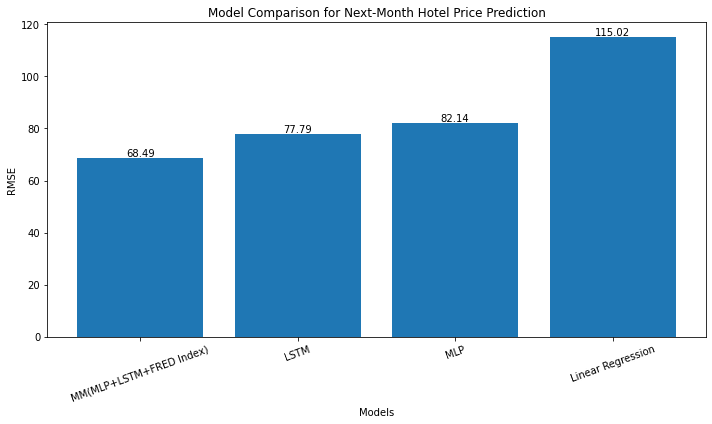

In [14]:
# Plot 1: main model comparison by RMSE
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(results_df["Model"], results_df["RMSE"])

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.2f}", ha="center", va="bottom")

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison for Next-Month Hotel Price Prediction")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


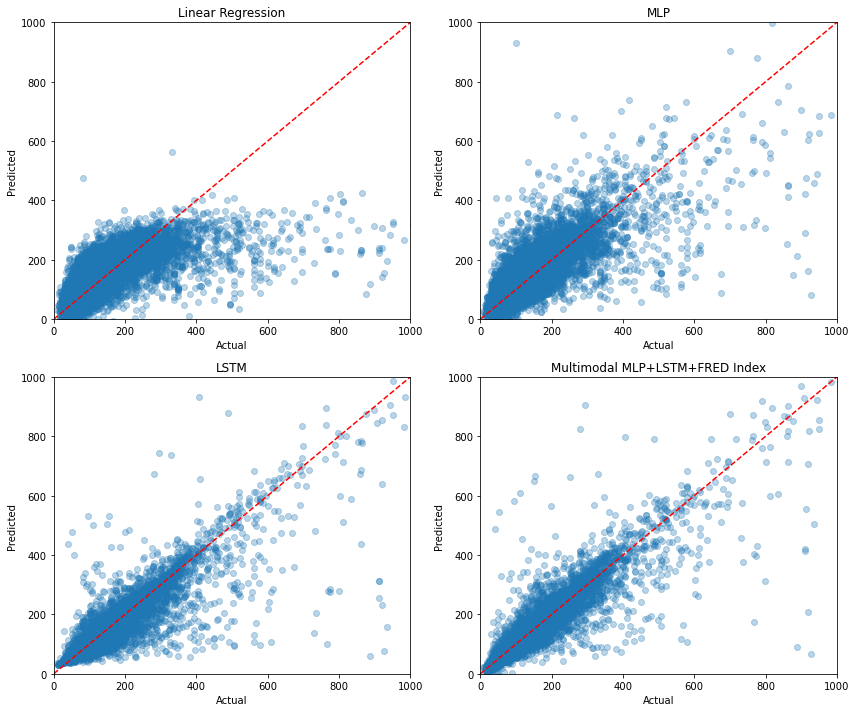

In [15]:
# Plot 2: actual vs predicted
plt.figure(figsize=(12, 10))

# 1 Linear Regression
plt.subplot(2, 2, 1)
plt.scatter(y_test_tab, pred_lr, alpha=0.3)
plt.plot([0, 1000], [0, 1000], "r--")
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xlim(0, 1000)
plt.ylim(0, 1000)

# 2 MLP
plt.subplot(2, 2, 2)
plt.scatter(y_test_tab, pred_mlp, alpha=0.3)
plt.plot([0, 1000], [0, 1000], "r--")
plt.title("MLP")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xlim(0, 1000)
plt.ylim(0, 1000)

# 3 LSTM
plt.subplot(2, 2, 3)
plt.scatter(y_test_real, pred_lstm, alpha=0.3)
plt.plot([0, 1000], [0, 1000], "r--")
plt.title("LSTM")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xlim(0, 1000)
plt.ylim(0, 1000)

# 4 Multimodal
plt.subplot(2, 2, 4)
plt.scatter(y_test_real, pred_fusion, alpha=0.3)
plt.plot([0, 1000], [0, 1000], "r--")
plt.title("Multimodal MLP+LSTM+FRED Index")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xlim(0, 1000)
plt.ylim(0, 1000)

plt.tight_layout()
plt.show()


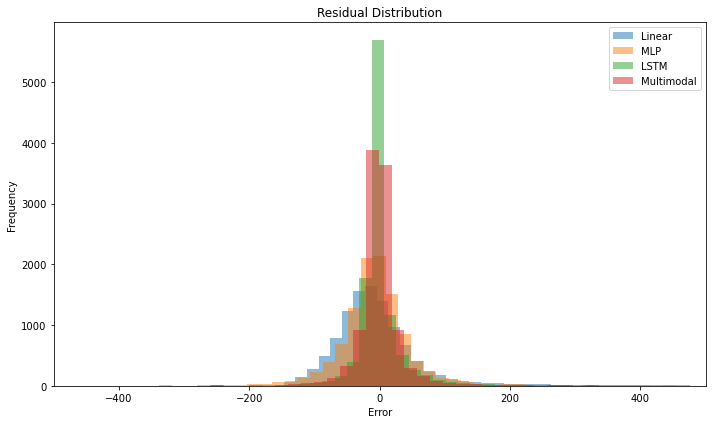

In [16]:
# Plot 3: residual distribution
err_lr = y_test_tab - pred_lr
err_mlp = y_test_tab - pred_mlp
err_lstm = y_test_real - pred_lstm
err_mm = y_test_real - pred_fusion

plt.figure(figsize=(10, 6))

limit = 500
mask_lr = np.abs(err_lr) < limit
mask_mlp = np.abs(err_mlp) < limit
mask_lstm = np.abs(err_lstm) < limit
mask_mm = np.abs(err_mm) < limit

plt.hist(err_lr[mask_lr], bins=50, alpha=0.5, label="Linear")
plt.hist(err_mlp[mask_mlp], bins=50, alpha=0.5, label="MLP")
plt.hist(err_lstm[mask_lstm], bins=50, alpha=0.5, label="LSTM")
plt.hist(err_mm[mask_mm], bins=50, alpha=0.5, label="Multimodal")

plt.legend()
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.xlim(-500, 500)
plt.tight_layout()
plt.show()


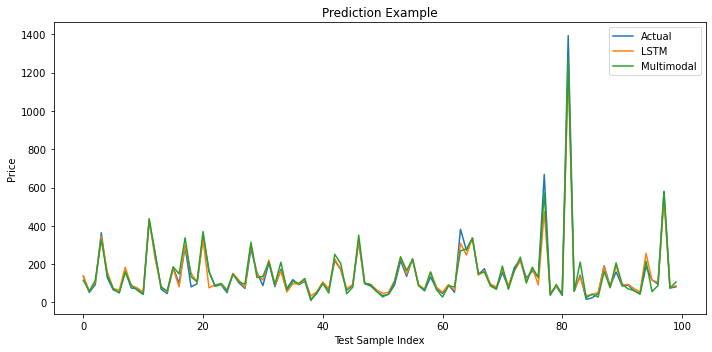

In [17]:
# Plot 4: time-series prediction example
plt.figure(figsize=(10, 5))
plt.plot(y_test_real[:100], label="Actual")
plt.plot(pred_lstm[:100], label="LSTM")
plt.plot(pred_fusion[:100], label="Multimodal")
plt.legend()
plt.title("Prediction Example")
plt.xlabel("Test Sample Index")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


In [18]:
# Predict next-month hotel price using the trained multimodal model

def predict_next_month_price(hotel_id, future_feature_overrides=None):
    """
    Predict next-month hotel price for one hotel.

    Parameters
    ----------
    hotel_id : selected hotel_id from df_full
    future_feature_overrides : optional dict
        Used when you want to manually set known future features,
        such as weekend, holiday, nnights, scarce_room, offer, etc.

    Returns
    -------
    dict containing hotel_id, forecast origin, target month, and predicted price.
    """

    if future_feature_overrides is None:
        future_feature_overrides = {}

    # 1. Get this hotel's historical records
    group = df_full[df_full["hotel_id"] == hotel_id].sort_values(["year", "month"]).reset_index(drop=True)

    if len(group) < sequence_length:
        raise ValueError(f"Hotel {hotel_id} does not have enough history for sequence_length={sequence_length}.")

    # 2. Use the latest available month as forecast origin
    latest_row = group.iloc[-1]

    origin_year = int(latest_row["year"])
    origin_month = int(latest_row["month"])

    # 3. Calculate next month
    origin_period = pd.Period(year=origin_year, month=origin_month, freq="M")
    target_period = origin_period + prediction_horizon

    target_year = target_period.year
    target_month = target_period.month

    # 4. Use the latest sequence_length prices as LSTM input
    hist_prices = group["price"].tail(sequence_length).values

    X_seq_future = hist_prices.reshape(1, sequence_length, 1)
    X_seq_future_scaled = scaler_x.transform(
        X_seq_future.reshape(-1, 1)
    ).reshape(1, sequence_length, 1)

    # 5. Build future tabular row
    future_row = {}

    for col in base_tabular_cols:
        if col == "year":
            future_row[col] = target_year
        elif col == "month":
            future_row[col] = target_month
        else:
            # By default, use latest known value
            future_row[col] = latest_row[col]

    # FRED variables use latest available month to avoid future leakage
    for col in exogenous_cols:
        future_row[col] = latest_row[col]

    # Manually override future features if provided
    for key, value in future_feature_overrides.items():
        future_row[key] = value

    X_future_raw = pd.DataFrame([future_row])

    # 6. One-hot encode categorical variables consistently with training
    combined_raw = pd.concat(
        [aligned_df[tabular_cols].copy(), X_future_raw[tabular_cols].copy()],
        ignore_index=True
    )

    combined_encoded = pd.get_dummies(
        combined_raw,
        columns=categorical_cols,
        drop_first=True
    )

    X_future_encoded = combined_encoded.iloc[[-1]]

    # Align with training columns
    X_future_encoded = X_future_encoded.reindex(columns=X_tab.columns, fill_value=0)

    X_future_encoded = X_future_encoded.replace([np.inf, -np.inf], np.nan)
    X_future_encoded = X_future_encoded.fillna(X_tab.mean(numeric_only=True))
    X_future_encoded = X_future_encoded.fillna(0)

    # 7. Scale tabular features
    X_future_tab_scaled = scaler_fusion_tab.transform(X_future_encoded)

    # 8. Predict
    pred_scaled = model_fusion.predict(
        [X_future_tab_scaled, X_seq_future_scaled],
        verbose=0
    ).flatten()

    pred_price = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()[0]

    return {
        "hotel_id": hotel_id,
        "origin_year": origin_year,
        "origin_month": origin_month,
        "target_year": target_year,
        "target_month": target_month,
        "predicted_next_month_price": pred_price
    }

In [20]:
prediction = predict_next_month_price(
    hotel_id=12345,
    future_feature_overrides={
        "weekend": 1,
        "holiday": 0,
        "nnights": 2,
        "scarce_room": 0
    }
)

prediction

{'hotel_id': 12345,
 'origin_year': 2018,
 'origin_month': 6,
 'target_year': 2018,
 'target_month': 7,
 'predicted_next_month_price': 70.06969}